In [1]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score


In [2]:
# Read data
cluster_df = pd.read_parquet('cluster_used_data.parquet')

# Fetch feature columns
features = [col for col in cluster_df.columns if col not in ['symbol', 'report_date']]

print(f"Total features: {len(features)}")
print(f"Features: {features}")

# Normalization
scaler = StandardScaler()
df_normalized = cluster_df.copy()
df_normalized[features] = scaler.fit_transform(cluster_df[features])

# Fetch symbols
symbols = cluster_df['symbol'].unique()
n_symbols = len(symbols)

print(f"Total symbols: {n_symbols}")
print(f"Symbols: {list(symbols)}")


Total features: 7
Features: ['DE', 'NCOS', 'PNNIS', 'STA', 'ICSNW', 'NITN', 'CASH_PER_SHARE']
Total symbols: 50
Symbols: ['000063', '000333', '000617', '000725', '000792', '000938', '002027', '002230', '002371', '002475', '002594', '002714', '300015', '300124', '300408', '300750', '300760', '600009', '600019', '600028', '600030', '600031', '600036', '600048', '600111', '600276', '600309', '600406', '600415', '600426', '600436', '600519', '600585', '600660', '600887', '600893', '600900', '600941', '601012', '601088', '601318', '601600', '601668', '601766', '601816', '601888', '601899', '603259', '605499', '688981']


In [3]:
def eros_distance(mat1, mat2, n_components=None):
    """
    Calculate EROS (Extended Frobenius Norm based on Subspaces) distance between two matrices.
    
    Steps:
    1. Compute covariance matrix for each stock's time series
    2. Perform PCA (eigenvalue decomposition) to get principal components
    3. Calculate cosine similarity between corresponding eigenvectors
    4. Weight by eigenvalue contribution ratio
    5. Sum weighted similarities to get final distance
    
    Args:
        mat1, mat2: numpy arrays of shape (n_periods, n_features)
        n_components: number of principal components to use (if None, use all)
    
    Returns:
        scalar distance value (1 - weighted cosine similarity)
    """
    # Step 1: Compute covariance matrices
    cov1 = np.cov(mat1.T)  # Transpose to get covariance of features
    cov2 = np.cov(mat2.T)
    
    # Step 2: PCA - eigenvalue decomposition
    # eigenvalues shape: (n_features,)
    # eigenvectors shape: (n_features, n_features)
    eigenvalues1, eigenvectors1 = np.linalg.eigh(cov1)
    eigenvalues2, eigenvectors2 = np.linalg.eigh(cov2)
    
    # Sort in descending order
    idx1 = np.argsort(eigenvalues1)[::-1]
    idx2 = np.argsort(eigenvalues2)[::-1]
    
    eigenvalues1 = eigenvalues1[idx1]
    eigenvalues2 = eigenvalues2[idx2]
    eigenvectors1 = eigenvectors1[:, idx1]
    eigenvectors2 = eigenvectors2[:, idx2]
    
    # Determine number of components to use
    if n_components is None:
        n_components = len(eigenvalues1)
    
    n_components = min(n_components, len(eigenvalues1), len(eigenvalues2))
    
    # Step 3 & 4: Calculate weighted cosine similarities
    total_similarity = 0.0
    
    for i in range(n_components):
        # Get eigenvectors for component i
        vec1 = eigenvectors1[:, i]  # Shape: (n_features,)
        vec2 = eigenvectors2[:, i]  # Shape: (n_features,)
        
        # Calculate cosine similarity
        # cosine_sim = (vec1 · vec2) / (||vec1|| * ||vec2||)
        cosine_sim = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
        
        # Calculate weight based on eigenvalue contribution ratio
        # weight = (λ1_i + λ2_i) / (sum(λ1) + sum(λ2))
        weight = (eigenvalues1[i] + eigenvalues2[i]) / (np.sum(eigenvalues1) + np.sum(eigenvalues2))
        
        # Accumulate weighted similarity
        total_similarity += weight * cosine_sim
    
    # Step 5: Convert similarity to distance
    # Distance = 1 - similarity (so larger distance = less similar)
    distance = 1.0 - total_similarity
    
    return max(0.0, distance)  # Ensure distance is non-negative



In [4]:

# Calculate EROS distance matrix
distance_matrix = np.zeros((n_symbols, n_symbols))

# Determine optimal number of components (optional)
# You can set this to a fixed value or determine automatically
n_comp = None  # Use all components

print("Calculating EROS distance matrix...")
for i, sym1 in tqdm(enumerate(symbols), desc='Symbol 1', total=n_symbols):
    for j, sym2 in tqdm(enumerate(symbols), desc='Symbol 2', total=n_symbols, leave=False):
        if i >= j:
            continue
        
        # Fetch time series (matrices) for both symbols
        mat1 = df_normalized[df_normalized['symbol'] == sym1][features].values
        mat2 = df_normalized[df_normalized['symbol'] == sym2][features].values
        
        # Calculate EROS distance
        distance = eros_distance(mat1, mat2, n_components=n_comp)
        
        distance_matrix[i, j] = distance
        distance_matrix[j, i] = distance

print("Distance Matrix Shape:", distance_matrix.shape)
print("Distance Matrix (first 5x5):\n", distance_matrix[:5, :5])
print(f"\nDistance Matrix Statistics:")
print(f"Min: {distance_matrix[distance_matrix > 0].min():.4f}")
print(f"Max: {distance_matrix.max():.4f}")
print(f"Mean: {distance_matrix[distance_matrix > 0].mean():.4f}")
print(f"Median: {np.median(distance_matrix[distance_matrix > 0]):.4f}")


Calculating EROS distance matrix...


Symbol 1: 100%|██████████| 50/50 [00:02<00:00, 23.00it/s]

Distance Matrix Shape: (50, 50)
Distance Matrix (first 5x5):
 [[0.         0.07345626 0.99688375 0.97267032 0.49756846]
 [0.07345626 0.         1.00564422 1.00670612 0.25787903]
 [0.99688375 1.00564422 0.         1.00087886 1.02047276]
 [0.97267032 1.00670612 1.00087886 0.         0.99954347]
 [0.49756846 0.25787903 1.02047276 0.99954347 0.        ]]

Distance Matrix Statistics:
Min: 0.0200
Max: 1.9942
Mean: 0.9977
Median: 0.9974


c:\BASIC_LEARNING\DSA5101\Project2\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


MDS Embeddings Shape: (50, 2)
MDS Explained Variance Ratio: 41.7617


Finding optimal K: 100%|██████████| 6/6 [00:02<00:00,  2.39it/s]



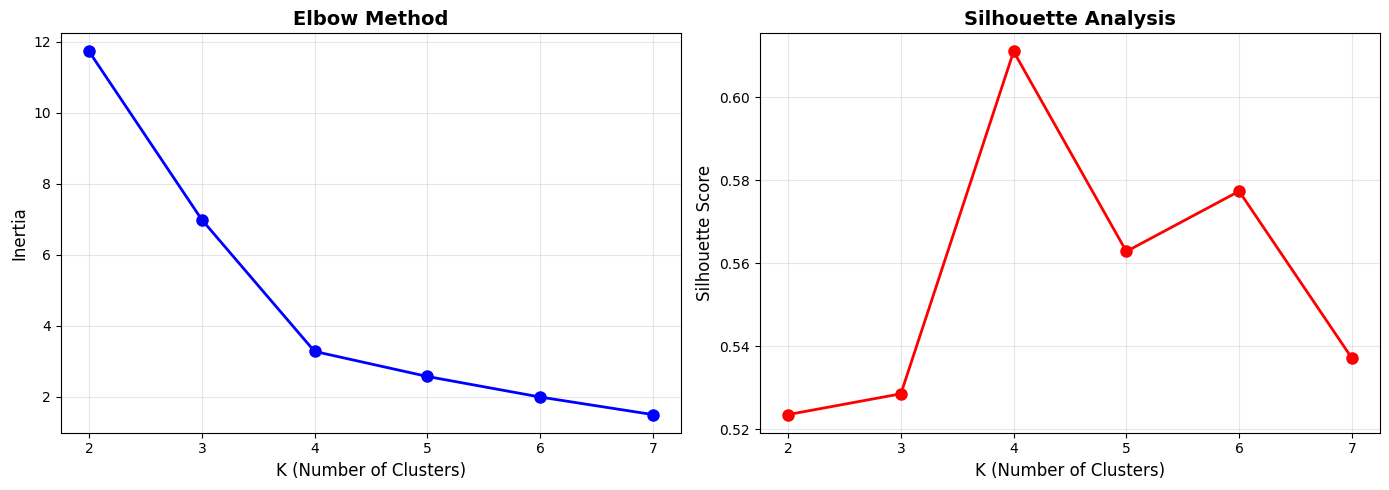


Optimal K (by Silhouette Score): 4
Silhouette Score at K=4: 0.6110


In [5]:
# MDS dimension reduction
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
embeddings = mds.fit_transform(distance_matrix)

print(f"MDS Embeddings Shape: {embeddings.shape}")
#print(f"MDS Explained Variance Ratio: {mds.stress_:.4f}")

# Find optimal K using Elbow Method and Silhouette Score
inertias = []
silhouette_scores = []
k_range = range(2, min(8, n_symbols))

for k in tqdm(k_range, desc='Finding optimal K'):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(embeddings, labels))

# Plot inertias and silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('K (Number of Clusters)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)

ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('K (Number of Clusters)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Choose optimal K according to silhouette scores
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nOptimal K (by Silhouette Score): {optimal_k}")
print(f"Silhouette Score at K={optimal_k}: {max(silhouette_scores):.4f}")


In [6]:
# Final clustering with optimal K
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(embeddings)

# Output results
result_df = pd.DataFrame({
    'symbol': symbols,
    'cluster': cluster_labels
})

print("\n" + "="*50)
print("CLUSTERING RESULTS")
print("="*50)
print(result_df.to_string(index=False))

# Cluster statistics
print("\n" + "="*50)
print("CLUSTER STATISTICS")
print("="*50)
for cluster_id in range(optimal_k):
    cluster_symbols = result_df[result_df['cluster'] == cluster_id]['symbol'].tolist()
    print(f"Cluster {cluster_id}: {len(cluster_symbols)} stocks")
    print(f"  Symbols: {', '.join(cluster_symbols)}")
    print()



CLUSTERING RESULTS
symbol  cluster
000063        0
000333        0
000617        2
000725        2
000792        0
000938        0
002027        0
002230        3
002371        2
002475        0
002594        2
002714        1
300015        1
300124        0
300408        1
300750        3
300760        0
600009        3
600019        0
600028        1
600030        3
600031        1
600036        3
600048        0
600111        0
600276        1
600309        1
600406        0
600415        2
600426        1
600436        2
600519        3
600585        1
600660        1
600887        1
600893        3
600900        1
600941        3
601012        1
601088        1
601318        2
601600        0
601668        1
601766        1
601816        3
601888        0
601899        0
603259        1
605499        0
688981        3

CLUSTER STATISTICS
Cluster 0: 16 stocks
  Symbols: 000063, 000333, 000792, 000938, 002027, 002475, 300124, 300760, 600019, 600048, 600111, 600406, 601600, 601888, 

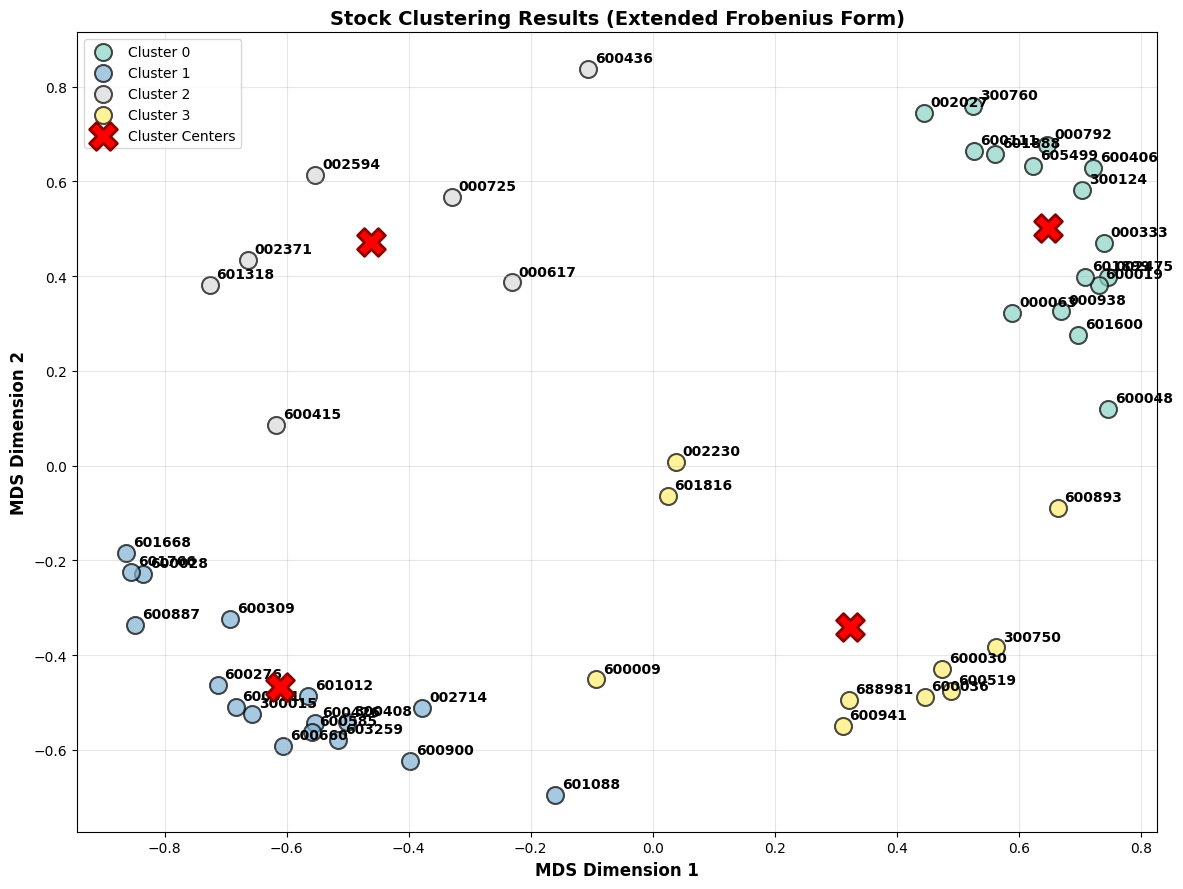

Clustering visualization completed!
Total Silhouette Score: 0.6110


In [7]:
# Visualize clustering results
plt.figure(figsize=(12, 9))
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))

for cluster_id in range(optimal_k):
    mask = cluster_labels == cluster_id
    plt.scatter(embeddings[mask, 0], embeddings[mask, 1], 
               label=f'Cluster {cluster_id}', s=150, alpha=0.7, 
               color=colors[cluster_id], edgecolors='black', linewidth=1.5)
    
    # Annotate stock symbols
    for idx, sym in enumerate(symbols[mask]):
        plt.annotate(sym, 
                    (embeddings[mask][idx, 0], embeddings[mask][idx, 1]),
                    fontsize=10, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points')

# Plot cluster centers
centers_embedded = final_kmeans.cluster_centers_
plt.scatter(centers_embedded[:, 0], centers_embedded[:, 1], 
           marker='X', s=400, c='red', edgecolors='darkred', 
           linewidth=2, label='Cluster Centers', zorder=5)

plt.xlabel('MDS Dimension 1', fontsize=12, fontweight='bold')
plt.ylabel('MDS Dimension 2', fontsize=12, fontweight='bold')
plt.title('Stock Clustering Results (Extended Frobenius Form)', 
         fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Clustering visualization completed!")
print(f"Total Silhouette Score: {silhouette_score(embeddings, cluster_labels):.4f}")


In [ ]:
result_df.to_parquet('eros_kmeans_results.parquet')
print("Results(stocks belong to which cluster) saved to 'eros_kmeans_results.parquet'")


Results(stocks belong to which cluster) saved to 'eros_kmeans_results.parquet'
